In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit
from src.kalman_network_tools import get_risk_mat_from_df
from src.classification_tools import plot_roc_curves

# Run Simulations

In [2]:
with open(r'saves\monday_freq_1000.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

991

In [177]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle)
len(entity_names)

13

In [175]:
import importlib, src
import src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import*

In [6]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'
t_graph = 100
sync_window_size = 1
time_scale= 'sec'

df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')

In [179]:


risk_mat, labels, labels_count, _, _, date_times, t_sim = get_risk_mat_from_df(df, entity_names=entity_names,
    t_graph = t_graph, time_scale= time_scale, sync_window_size = sync_window_size, return_datetimes = True, timeit= True)

1
Current time and samples shape:  2017-04-07 01:02:00 (100, 13)
2
Current time and samples shape:  2017-04-07 01:04:00 (100, 13)
3
Current time and samples shape:  2017-04-07 01:06:00 (100, 13)
4
Current time and samples shape:  2017-04-07 01:08:00 (100, 13)
5
Current time and samples shape:  2017-04-07 01:10:00 (100, 13)
6
Current time and samples shape:  2017-04-07 01:12:00 (100, 13)
7
Current time and samples shape:  2017-04-07 01:14:00 (100, 13)
8
Current time and samples shape:  2017-04-07 01:16:00 (100, 13)
9
Current time and samples shape:  2017-04-07 01:18:00 (100, 13)
10
Current time and samples shape:  2017-04-07 01:20:00 (100, 13)
11
Current time and samples shape:  2017-04-07 01:22:00 (100, 13)
12
Current time and samples shape:  2017-04-07 01:24:00 (100, 13)
13
Current time and samples shape:  2017-04-07 01:26:00 (100, 13)
14
Current time and samples shape:  2017-04-07 01:28:00 (100, 13)
15
Current time and samples shape:  2017-04-07 01:30:00 (100, 13)
16
Current time and

125
Current time and samples shape:  2017-04-07 09:01:00 (100, 13)
126
Current time and samples shape:  2017-04-07 09:03:00 (100, 13)
127
Current time and samples shape:  2017-04-07 09:05:00 (100, 13)
128
Current time and samples shape:  2017-04-07 09:07:00 (100, 13)
129
Current time and samples shape:  2017-04-07 09:09:00 (100, 13)
130
Current time and samples shape:  2017-04-07 09:11:00 (100, 13)
131
Current time and samples shape:  2017-04-07 09:13:00 (100, 13)
132
Current time and samples shape:  2017-04-07 09:15:00 (100, 13)
133
Current time and samples shape:  2017-04-07 09:17:00 (100, 13)
134
Current time and samples shape:  2017-04-07 09:19:00 (100, 13)
135
Current time and samples shape:  2017-04-07 09:21:00 (100, 13)
136
Current time and samples shape:  2017-04-07 09:23:00 (100, 13)
137
Current time and samples shape:  2017-04-07 09:25:00 (100, 13)
138
Current time and samples shape:  2017-04-07 09:27:00 (100, 13)
139
Current time and samples shape:  2017-04-07 09:29:00 (100,

In [7]:
#num_nodes_list = [20, 200]
num_nodes_list = [int(val)for val in np.logspace(np.log10(50), np.log10(900), 10)]
node_space = entity_names
N_trial = 1
conn_param = 'NPR'
mthds = ['cov']#, 'mi']

t_windows = [(500, 1)]#[(100, 1), (100, 5), (200, 1), (200, 5), (500, 1), (500, 5)] # T_graph, TW
#T_windows = [(int(T_graph), int(TW)) for T_graph in np.arange(100, 600, 100) for TW in np.arange(1, 6, 1)]

In [8]:
""" Span the test parameters and calculate running times"""
df_run_time = pd.DataFrame(columns= ['T_graph', 'T_batch', '# of nodes', 'Method', 't_graph', 't_sim'])
for t_graph, tw in t_windows:
    for n_nodes in num_nodes_list: # do with tqdm
        print('T_graph: ', t_graph, ', TW: ', tw, ', Num of nodes: ', n_nodes)
        for n_trial in range(N_trial):
            print('Trial: ', n_trial+1)
            samp_nodes = np.random.permutation(node_space)[:n_nodes]
            samp_nodes = list(samp_nodes)
            for method in mthds:
                _, _, _, _, _, time_graph, t_sim = get_risk_mat_from_df(df, entity_names=entity_names,
                    conn_param= conn_param, method= method, t_graph= t_graph,
                    sync_window_size= tw, verbose= True, return_datetimes= True, timeit= True)
                df_run_time.loc[df_run_time.shape[0]] = [t_graph, tw, n_nodes, method, time_graph[:-1], t_sim]

mthd_dict = {'cov': 'Corr. Coeff.', 'mi': 'MI'}
df_run_time['Method'] = df_run_time['Method'].apply(lambda x: mthd_dict[x])

T_graph:  500 , TW:  1 , Num of nodes:  49
Trial:  1
1
Current time and samples shape:  2017-04-07 01:09:00 (500, 991)
2
Current time and samples shape:  2017-04-07 01:18:00 (500, 991)
3
Current time and samples shape:  2017-04-07 01:27:00 (500, 991)
4
Current time and samples shape:  2017-04-07 01:36:00 (500, 991)
5
Current time and samples shape:  2017-04-07 01:45:00 (500, 991)
6
Current time and samples shape:  2017-04-07 01:54:00 (500, 991)
7
Current time and samples shape:  2017-04-07 02:03:00 (500, 991)
8
Current time and samples shape:  2017-04-07 02:12:00 (500, 991)
9
Current time and samples shape:  2017-04-07 02:21:00 (500, 991)
10
Current time and samples shape:  2017-04-07 02:30:00 (500, 991)
11
Current time and samples shape:  2017-04-07 02:39:00 (500, 991)
12
Current time and samples shape:  2017-04-07 02:48:00 (500, 991)
13
Current time and samples shape:  2017-04-07 02:57:00 (500, 991)
14
Current time and samples shape:  2017-04-07 03:06:00 (500, 991)
15
Current time an

12
Current time and samples shape:  2017-04-07 02:48:00 (500, 991)
13
Current time and samples shape:  2017-04-07 02:57:00 (500, 991)
14
Current time and samples shape:  2017-04-07 03:06:00 (500, 991)
15
Current time and samples shape:  2017-04-07 03:15:00 (500, 991)
16
Current time and samples shape:  2017-04-07 03:24:00 (500, 991)
17
Current time and samples shape:  2017-04-07 03:33:00 (500, 991)
18
Current time and samples shape:  2017-04-07 03:42:00 (500, 991)
19
Current time and samples shape:  2017-04-07 03:51:00 (500, 991)
20
Current time and samples shape:  2017-04-07 04:00:00 (500, 991)
21
Current time and samples shape:  2017-04-07 04:09:00 (500, 991)
22
Current time and samples shape:  2017-04-07 04:18:00 (500, 991)
23
Current time and samples shape:  2017-04-07 04:27:00 (500, 991)
24
Current time and samples shape:  2017-04-07 04:36:00 (500, 991)
25
Current time and samples shape:  2017-04-07 04:45:00 (500, 991)
26
Current time and samples shape:  2017-04-07 04:54:00 (500, 

23
Current time and samples shape:  2017-04-07 04:27:00 (500, 991)
24
Current time and samples shape:  2017-04-07 04:36:00 (500, 991)
25
Current time and samples shape:  2017-04-07 04:45:00 (500, 991)
26
Current time and samples shape:  2017-04-07 04:54:00 (500, 991)
27
Current time and samples shape:  2017-04-07 08:53:00 (500, 991)
28
Current time and samples shape:  2017-04-07 09:02:00 (500, 991)
29
Current time and samples shape:  2017-04-07 09:11:00 (500, 991)
30
Current time and samples shape:  2017-04-07 09:20:00 (500, 991)
31
Current time and samples shape:  2017-04-07 09:29:00 (500, 991)
32
Current time and samples shape:  2017-04-07 09:38:00 (500, 991)
33
Current time and samples shape:  2017-04-07 09:47:00 (500, 991)
34
Current time and samples shape:  2017-04-07 09:56:00 (500, 991)
35
Current time and samples shape:  2017-04-07 10:05:00 (500, 991)
36
Current time and samples shape:  2017-04-07 10:14:00 (500, 991)
37
Current time and samples shape:  2017-04-07 10:23:00 (500, 

34
Current time and samples shape:  2017-04-07 09:56:00 (500, 991)
35
Current time and samples shape:  2017-04-07 10:05:00 (500, 991)
36
Current time and samples shape:  2017-04-07 10:14:00 (500, 991)
37
Current time and samples shape:  2017-04-07 10:23:00 (500, 991)
38
Current time and samples shape:  2017-04-07 10:32:00 (500, 991)
39
Current time and samples shape:  2017-04-07 10:41:00 (500, 991)
40
Current time and samples shape:  2017-04-07 10:50:00 (500, 991)
41
Current time and samples shape:  2017-04-07 10:59:00 (500, 991)
42
Current time and samples shape:  2017-04-07 11:08:00 (500, 991)
43
Current time and samples shape:  2017-04-07 11:17:00 (500, 991)
44
Current time and samples shape:  2017-04-07 11:26:00 (500, 991)
45
Current time and samples shape:  2017-04-07 11:35:00 (500, 991)
46
Current time and samples shape:  2017-04-07 11:44:00 (500, 991)
47
Current time and samples shape:  2017-04-07 11:53:00 (500, 991)
48
Current time and samples shape:  2017-04-07 12:02:00 (500, 

45
Current time and samples shape:  2017-04-07 11:35:00 (500, 991)
46
Current time and samples shape:  2017-04-07 11:44:00 (500, 991)
47
Current time and samples shape:  2017-04-07 11:53:00 (500, 991)
48
Current time and samples shape:  2017-04-07 12:02:00 (500, 991)
49
Current time and samples shape:  2017-04-07 12:11:00 (500, 991)
50
Current time and samples shape:  2017-04-07 12:20:00 (500, 991)
51
Current time and samples shape:  2017-04-07 12:29:00 (500, 991)
52
Current time and samples shape:  2017-04-07 12:38:00 (500, 991)
53
Current time and samples shape:  2017-04-07 12:47:00 (500, 991)
54
Current time and samples shape:  2017-04-07 12:56:00 (500, 991)
55
Current time and samples shape:  2017-04-07 12:59:00 (500, 991)
T_graph:  500 , TW:  1 , Num of nodes:  899
Trial:  1
1
Current time and samples shape:  2017-04-07 01:09:00 (500, 991)
2
Current time and samples shape:  2017-04-07 01:18:00 (500, 991)
3
Current time and samples shape:  2017-04-07 01:27:00 (500, 991)
4
Current t

In [9]:
avg_dt_sim = []
se_dt_sim = []
for index, row in df_run_time.iterrows():
    t_graph = row.iloc[4]
    t_graph = [(t_graph[i] - t_graph[0]).total_seconds() for i in range(len(t_graph))]
    t_sim = row.iloc[5]
    assert len(t_graph) == len(t_sim)
    dt_graph, dt_sim = np.diff(t_graph), np.diff(t_sim)
    avg_dt_sim.append(np.mean(dt_sim))
    se_dt_sim.append(np.std(dt_sim, ddof= 1)/ np.sqrt(len(dt_sim)))
df_run_time['Avg. Sim. Time'] = avg_dt_sim
df_run_time['SE Sim. Time'] = se_dt_sim

df_run_time

,T_graph,T_batch,# of nodes,Method,t_graph,t_sim,Avg. Sim. Time,SE Sim. Time
0,500,1,49,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.773259162902832, 5.527685165405273, 8.22316...",3.216294,0.043272
1,500,1,68,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.683551788330078, 5.352905035018921, 8.10414...",3.453659,0.056267
2,500,1,95,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.5746452808380127, 5.415361404418945, 8.2735...",3.349570,0.047498
3,500,1,131,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.4863553047180176, 5.3022620677948, 7.987365...",3.244723,0.043888
4,500,1,180,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.7029709815979004, 5.281734466552734, 7.8706...",3.329888,0.054848
5,500,1,249,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.7586963176727295, 5.586445331573486, 8.6123...",3.514512,0.059219
6,500,1,343,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.6442277431488037, 5.437243938446045, 8.2863...",3.457510,0.046388
7,500,1,473,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.849705457687378, 5.98124623298645, 8.942232...",3.865554,0.108629
8,500,1,652,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[3.548452138900757, 6.741953372955322, 9.81053...",3.956326,0.084181
9,500,1,899,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.8584463596343994, 5.838298082351685, 8.6583...",3.512067,0.047042


In [11]:
import pickle

with open(r'saves\run_times_node_size3.pickle', 'wb') as handle:
    pickle.dump(df_run_time, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Analysis

For T_window

In [13]:
with open(r'saves\run_times.pickle', 'rb') as handle:
    #df_run_time = pickle.load(handle)
    df_run_time = pd.read_pickle(handle)

For network_size

In [2]:
with open(r'saves\run_times_node_size3.pickle', 'rb') as handle:
    df_run_time = pd.read_pickle(handle)

In [3]:
df_run_time.head()

,T_graph,T_batch,# of nodes,Method,t_graph,t_sim,Avg. Sim. Time,SE Sim. Time
0,500,1,49,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.773259162902832, 5.527685165405273, 8.22316...",3.216294,0.043272
1,500,1,68,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.683551788330078, 5.352905035018921, 8.10414...",3.453659,0.056267
2,500,1,95,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.5746452808380127, 5.415361404418945, 8.2735...",3.349570,0.047498
3,500,1,131,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.4863553047180176, 5.3022620677948, 7.987365...",3.244723,0.043888
4,500,1,180,Corr. Coeff.,"[2017-04-07 01:00:00, 2017-04-07 01:09:00, 201...","[2.7029709815979004, 5.281734466552734, 7.8706...",3.329888,0.054848


Network Size

<Axes: xlabel='# of nodes', ylabel='Avg. Sim. Time'>

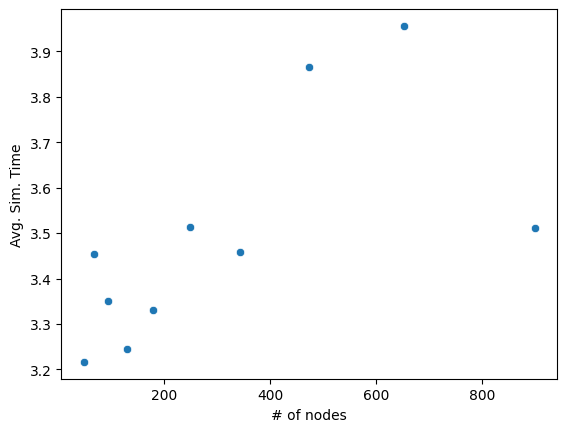

In [4]:
sns.scatterplot(data= df_run_time, x='# of nodes', y='Avg. Sim. Time')

In [10]:
df_run_time['log # of nodes'].values

array([1.69019608, 1.83250891, 1.97772361, 2.1172713 , 2.25527251,
       2.39619935, 2.53529412, 2.67486114, 2.8142476 , 2.95375969])

[0.05072595]


TypeError: unsupported format string passed to numpy.ndarray.__format__

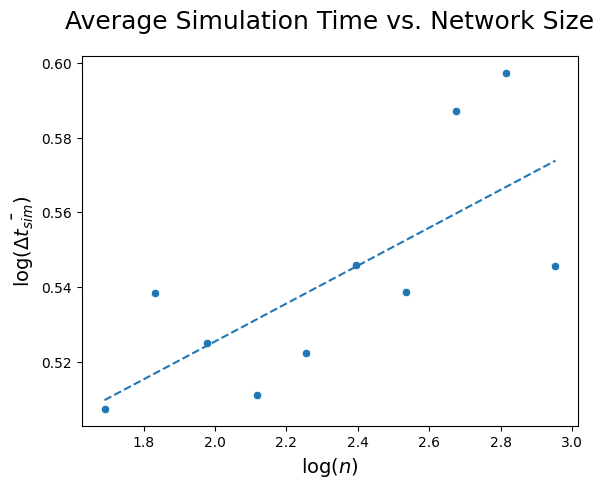

In [12]:
from sklearn.linear_model import LinearRegression

df_run_time['log Avg. Sim. Time'] = np.log10(df_run_time['Avg. Sim. Time'])
df_run_time['log # of nodes'] = np.log10(df_run_time['# of nodes'].astype(float))
sns.scatterplot(data= df_run_time, x='log # of nodes', y='log Avg. Sim. Time')

log_ns = df_run_time['log # of nodes'].values.reshape((-1, 1))
log_ts = df_run_time['log Avg. Sim. Time'].values

# Fit a line
regr = LinearRegression().fit(log_ns, log_ts)
xs = np.linspace(log_ns[0], log_ns[-1], 100)
ts = regr.predict(xs)
m = regr.coef_[0]
print(m)
plt.plot(xs, ts, '--')


plt.xlabel(r'$\log( n)$', fontsize = 14)
plt.ylabel(r'$\log(\Delta \bar{ t_{sim}})$', fontsize = 14)
plt.title('Average Simulation Time vs. Network Size', fontsize = 18, pad=20)
plt.annotate(r'slope ~ {:.2f}'.format(m), (1.7, 0.16), fontsize = 12)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [11]:
import plotly.express as px
import plotly

fig = px.scatter_3d(df_run_time, x='T_graph', y='T_batch', z='Avg. Sim. Time',
              color='Method')
fig.show()

plotly.offline.plot(fig, filename=r'saves\run_times_v_window_sizes.html')


'saves\\run_times_v_window_sizes.html'

Text(0.5, 1.0, 'Average Sim. Time vs. T_graph (T_batch = 1s)')

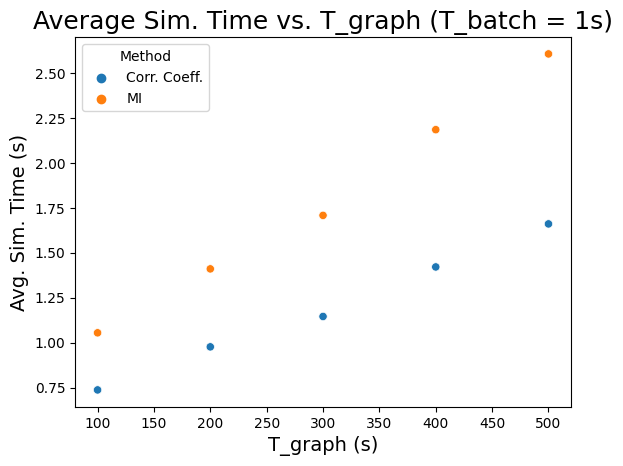

In [12]:
t_df = df_run_time[df_run_time['T_batch'] == 1]
sns.scatterplot(data= t_df, x='T_graph', y='Avg. Sim. Time', hue='Method')

plt.xlabel('T_graph (s)', fontsize = 14)
plt.ylabel('Avg. Sim. Time (s)', fontsize = 14)
plt.title('Average Sim. Time vs. T_graph (T_batch = 1s)', fontsize = 18)

Text(0.5, 1.0, 'Average Sim. Time vs. T_batch (T_graph = 500s)')

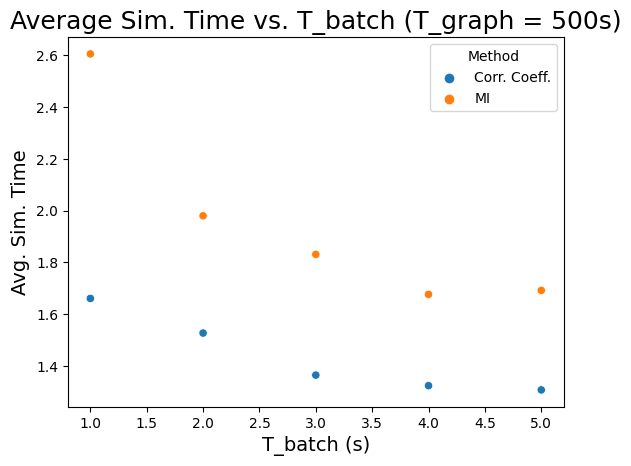

In [13]:
t_df = df_run_time[df_run_time['T_graph'] == 500]
sns.scatterplot(data= t_df, x='T_batch', y='Avg. Sim. Time', hue='Method')

plt.xlabel('T_batch (s)', fontsize = 14)
plt.ylabel('Avg. Sim. Time', fontsize = 14)
plt.title('Average Sim. Time vs. T_batch (T_graph = 500s)', fontsize = 18)

In [15]:
import importlib, src
import src.running_time

importlib.reload(src.running_time)
from src.running_time import*

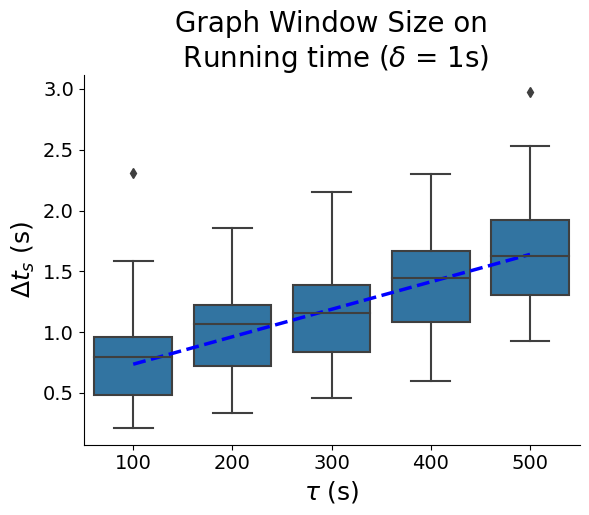

In [17]:
tt_df = slice_runtime_df(df_run_time[df_run_time['Method'] == 'Corr. Coeff.'], 'T_batch', 1, 'T_graph')
x_lines, y_lines = fit_lines_runtime_df(tt_df, 'T_graph')

sns.boxplot(data= tt_df, x='T_graph', y='dt_sim', hue='Method')
for i, c in enumerate(['blue']):
    sns.lineplot(x=x_lines[i], y=y_lines[i], linewidth = 2.5,  linestyle='--', color= c)

plt.xlabel(r'$\tau$ (s)', fontsize = 18)
plt.ylabel('$\Delta t_{s}$ (s)', fontsize = 18)
plt.title('Graph Window Size on\n Running time ($\delta$ = 1s)', fontsize = 20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().get_legend().remove()
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


In [19]:
tt_df = slice_runtime_df(df_run_time, 'T_graph', 500, 'T_batch')
tt_df = slice_runtime_df(df_run_time[df_run_time['Method'] == 'Corr. Coeff.'], 'T_graph', 500, 'T_batch')
col_sweep = 'T_batch'

# Fit 1/x curve
y_lines = []
x_lines = []
for mthd in np.unique(tt_df['Method']):
    x = (1/tt_df[tt_df['Method'] == mthd][col_sweep].values.astype(float)).reshape((-1, 1))
    y = tt_df[tt_df['Method'] == mthd]['dt_sim'].values

    model = LinearRegression().fit(x, y)
    x_line = np.array(list(map(lambda x: 1/x, np.unique(tt_df[col_sweep]).astype(float))))
    y_line = model.predict(x_line.reshape((-1, 1)))
    y_lines.append(y_line)
    x_lines.append(list(map(str, x_line)))

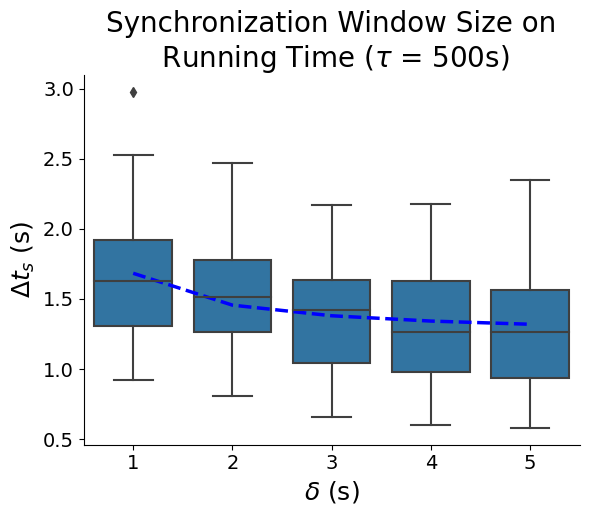

In [22]:

sns.boxplot(data= tt_df, x='T_batch', y='dt_sim', hue='Method')

for i, c in enumerate(['blue']):
    sns.lineplot(x=x_lines[i], y=y_lines[i], linewidth = 2.5,  linestyle='--', color= c)


plt.xlabel(r'$\delta$ (s)', fontsize = 18)
plt.ylabel('$\Delta t_{s}$ (s)', fontsize = 18)
plt.title('Synchronization Window Size on\n Running Time ' + r'($\tau$ = 500s)', fontsize = 20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().get_legend().remove()
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

Real Time Operability

255.30689730122862


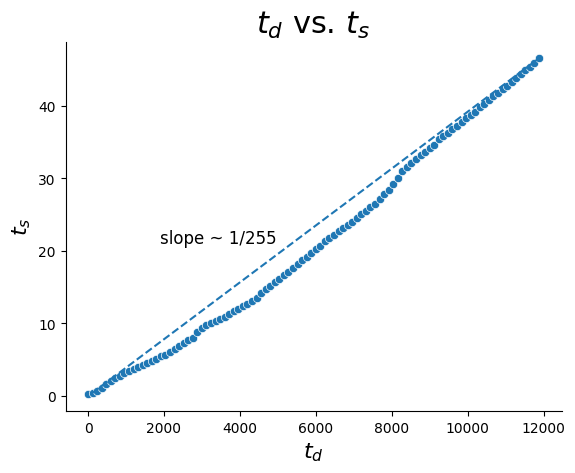

In [26]:
N = 100

t_graph = df_run_time['t_graph'][0][:N]
t_graph = [(t_graph[i] - t_graph[0]).total_seconds() for i in range(len(t_graph))]
t_sim = df_run_time['t_sim'][0][:N]
#plt.scatter(t_graph, t_sim)
sns.scatterplot(x=t_graph, y=t_sim)

m = (t_sim[-1] - t_sim[1])/(t_graph[-1] - t_graph[1])
print(1/m)
plt.annotate(r'slope ~ 1/{:.0f}'.format(1/m), (1900, 21), fontsize = 12)
ax = sns.lineplot(x=[t_graph[1], t_graph[-1]], y=[t_sim[-1] - m*(t_graph[-1] - t_graph[1]), t_sim[-1]])
ax.lines[0].set_linestyle("--")

plt.xlabel(r'$t_{d}$', fontsize= 16)
plt.ylabel(r'$t_{s}$', fontsize= 16)
plt.title(r'$t_{d}$ vs. $t_{s}$', fontsize = 22)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

Run time distributions

In [123]:
cols =list(df_run_time.columns)[:4]
cols.extend(['dt_graph', 'dt_sim'])
t_df = pd.DataFrame(columns= cols)
for index, row in df_run_time.iterrows():
    T_graph, TW, n_nodes, mthd= tuple(row)[:4]
    t_graph = row.iloc[4]
    t_graph = [(t_graph[i] - t_graph[0]).total_seconds() for i in range(len(t_graph))]
    t_sim = row.iloc[5]
    assert len(t_graph) == len(t_sim)
    dt_graph, dt_sim = np.diff(t_graph), np.diff(t_sim)
    for dt_g, dt_s in zip(dt_graph, dt_sim):
        t_df.loc[t_df.shape[0]] = [T_graph, TW, n_nodes, mthd, dt_g, dt_s]

t_df

,T_graph,T_batch,# of nodes,Method,dt_graph,dt_sim
0,100,1,20,Corr. Coeff.,120.0,0.220794
1,100,1,20,Corr. Coeff.,120.0,0.215443
2,100,1,20,Corr. Coeff.,120.0,0.412810
3,100,1,20,Corr. Coeff.,120.0,0.609117
4,100,1,20,Corr. Coeff.,120.0,0.361196
...,...,...,...,...,...,...
5865,500,5,20,MI,540.0,1.359824
5866,500,5,20,MI,540.0,1.485519
5867,500,5,20,MI,540.0,1.694236
5868,500,5,20,MI,540.0,2.369034


Text(0.5, 9.444444444444438, '$\\Delta t_{sim}$')

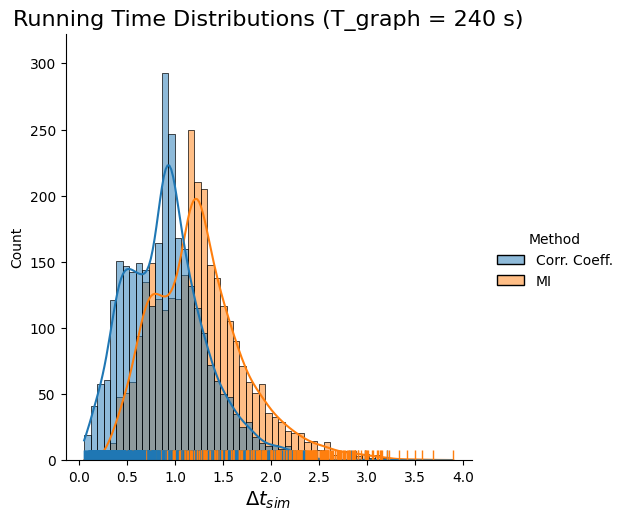

In [124]:

sns.displot(data= t_df, x='dt_sim', hue= 'Method', kde= True, rug= True)
plt.title('Running Time Distributions (T_graph = ' + str(int(np.median(t_df['dt_graph'])))+ ' s)', fontsize= 16)
plt.xlabel(r'$\Delta t_{sim}$', fontsize= 14)